## Clone the Repository

In [ ]:
#!git clone https://github.com/sovit-123/fastercnn-pytorch-training-pipeline.git

In [ ]:
!git clone https://github.com/sovit-123/vision_transformers

Cloning into 'vision_transformers'...
remote: Enumerating objects: 915, done.
remote: Counting objects: 100% (317/317), done.
remote: Compressing objects: 100% (233/233), done.
remote: Total 915 (delta 155), reused 188 (delta 81), pack-reused 598
Receiving objects: 100% (915/915), 44.31 MiB | 14.09 MiB/s, done.
Resolving deltas: 100% (529/529), done.


In [4]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
# Enter the repo directory.
%cd /content/gdrive/MyDrive/test_faster_rcnn_drowsiness

/content/gdrive/MyDrive/test_faster_rcnn_drowsiness


In [3]:
# Install the Requirements
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.3/776.3 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 61.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 89.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.4/952.4 kB 67.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 66.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 18.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 26.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.1/302.1 kB 35.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 12.5 MB/s eta 0:00:00
  Attempting uninstall: t

In [ ]:
#!pip install transformers

## Download the Dataset

Here we are using the [Aquarium Dataset](https://public.roboflow.com/object-detection/aquarium) from Roboflow.

Download the unzip the dataset to `custom_data` directory.

In [2]:
#!curl -L "https://public.roboflow.com/ds/CNyGy97q45?key=eSpwiC1Ah7" > roboflow.zip; unzip roboflow.zip -d custom_data; rm roboflow.zip

## Create the Custom Dataset YAML File.

In [5]:
%%writefile data_configs/custom_data.yaml
# Images and labels direcotry should be relative to train.py
TRAIN_DIR_IMAGES: '/content/gdrive/MyDrive/test_faster_rcnn_drowsiness/data/train'
TRAIN_DIR_LABELS: '/content/gdrive/MyDrive/test_faster_rcnn_drowsiness/data/train'
VALID_DIR_IMAGES: '/content/gdrive/MyDrive/test_faster_rcnn_drowsiness/data/valid'
VALID_DIR_LABELS: '/content/gdrive/MyDrive/test_faster_rcnn_drowsiness/data/valid'

# Class names.
CLASSES: [
    '__background__',
    '0', '1'
]

# Number of classes (object classes + 1 for background class in Faster RCNN).
NC: 3

# Whether to save the predictions of the validation set while training.
SAVE_VALID_PREDICTION_IMAGES: True

Overwriting data_configs/custom_data.yaml


In [ ]:
#!pip install vision_transformers

In [ ]:
#!pip install wandb

## Training

In [4]:
!wandb disabled
!python train.py --data data_configs/custom_data.yaml -e 1 -m fasterrcnn_resnet50_fpn -n custom_training -b 8

W&B disabled.
Please intall Vision Transformers to use MobileViT backbones
You can do pip install vision_transformers
Or visit the following link for the latest updates
https://github.com/sovit-123/vision_transformers
Not using distributed mode
device cuda
2024-07-22 14:37:21.590170: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-22 14:37:21.590217: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-22 14:37:21.591563: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-22 14:37:21.598869: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is o

In [ ]:
#!pip install vision_transformers

## Visualize Validation Results

In [5]:
import matplotlib.pyplot as plt
import glob as glob

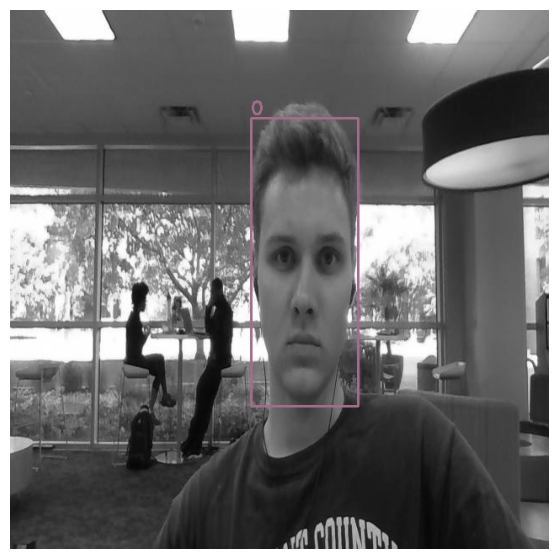

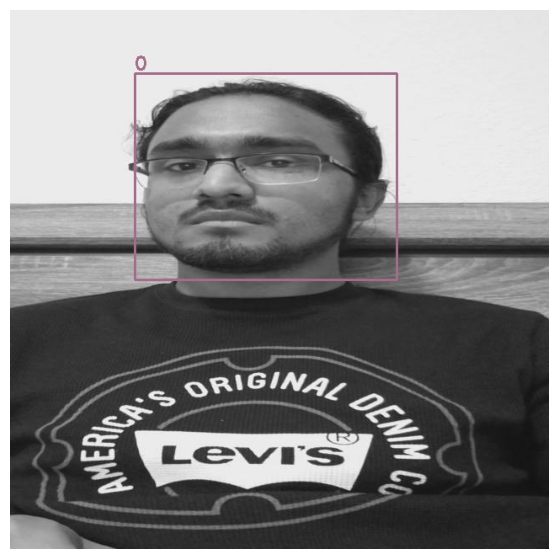

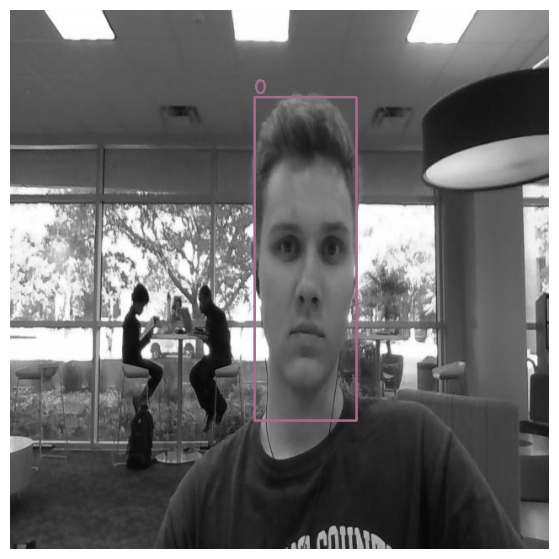

In [6]:
results_dir_path = '/content/gdrive/MyDrive/test_faster_rcnn_drowsiness/outputs/training/custom_training'
valid_images = glob.glob(f"{results_dir_path}/*.jpg")

for i in range(3):
    plt.figure(figsize=(10, 7))
    image = plt.imread(valid_images[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [10]:
!python eval.py --model fasterrcnn_resnet50_fpn --weights outputs/training/custom_training/best_model.pth --data data_configs/custom_data.yaml --batch 4 --verbose

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100% 54/54 [00:19<00:00,  2.78it/s]


{'classes': tensor([1, 2], dtype=torch.int32),
 'map': tensor(0.6753),
 'map_50': tensor(0.9847),
 'map_75': tensor(0.8651),
 'map_large': tensor(0.6839),
 'map_medium': tensor(-1.),
 'map_per_class': tensor([0.6699, 0.6807]),
 'map_small': tensor(-1.),
 'mar_1': tensor(0.7368),
 'mar_10': tensor(0.7368),
 'mar_100': tensor

In [10]:
!python inference.py --weights outputs/training/custom_training/best_model.pth --input data/valid/

Building from model name arguments...
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Test instances: 216
Image 1 done...
--------------------------------------------------
Image 2 done...
--------------------------------------------------
Image 3 done...
--------------------------------------------------
Image 4 done...
--------------------------------------------------
Image 5 done...
-----------

In [8]:
!pip install vision_transformers

  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━